In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [5]:
torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# 2. Load dataset
df = pd.read_csv("cleaned_data.csv")
df.head()

Using device: cpu


,label,text
0,0,conoco big cowboy darren sure help know else a...
1,0,feb 01 prod sale teco gas processing sale deal...
2,0,california energy crisis california  power cr...
3,0,nom actual volume april 23 rd agree eileen pon...
4,0,eastrans nomination changes effective 8 2 00 p...


In [6]:
# 3. Clean data
df = df.dropna(subset=["label"])
df["text"] = df["text"].fillna("").astype(str).str.lower()
df["label"] = df["label"].astype(str).str.lower().str.strip()

X = df["text"]
y = (df["label"] == "spam").astype(int)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (2998, 2)
  label                                               text
0     0  conoco big cowboy darren sure help know else a...
1     0  feb 01 prod sale teco gas processing sale deal...
2     0  california energy crisis california  power cr...
3     0  nom actual volume april 23 rd agree eileen pon...
4     0  eastrans nomination changes effective 8 2 00 p...


In [7]:
# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
# 5. Build vocabulary using training data only
max_words = 10000
max_len = 100

word_to_idx = {"<PAD>": 0, "<OOV>": 1}

for text in X_train:
    for word in re.findall(r"\b\w+\b", text):
        if word not in word_to_idx and len(word_to_idx) < max_words:
            word_to_idx[word] = len(word_to_idx)

vocab_size = len(word_to_idx)
print("Vocabulary size:", vocab_size)            

Vocabulary size: 10000


In [9]:
# 6. Convert text to padded sequences
def encode_text(text):
    words = re.findall(r"\b\w+\b", text.lower())

    sequence = [
        word_to_idx.get(word, word_to_idx["<OOV>"])
        for word in words
    ]

    # Truncate long messages
    sequence = sequence[:max_len]

    # Pad shorter messages
    sequence += [0] * (max_len - len(sequence))

    return sequence

In [10]:
X_train_seq = np.array(
    [encode_text(text) for text in X_train],
    dtype=np.int64
)

X_test_seq = np.array(
    [encode_text(text) for text in X_test],
    dtype=np.int64
)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

In [11]:
# 7. Convert to tensors
X_train_t = torch.tensor(X_train_seq, dtype=torch.long)
X_test_t = torch.tensor(X_test_seq, dtype=torch.long)

y_train_t = torch.tensor(
    y_train_np.reshape(-1, 1),
    dtype=torch.float32
)

y_test_t = torch.tensor(
    y_test_np.reshape(-1, 1),
    dtype=torch.float32
)


In [12]:
train_dataset = TensorDataset(X_train_t, y_train_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)



In [13]:
class SpamClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=32, hidden_dim=16):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        embedded = self.embedding(x)

        # output shape: (batch, sequence_length, hidden_dim)
        _, (hidden, cell) = self.lstm(embedded)

        # Final hidden state
        last_hidden = hidden[-1]

        x = self.fc1(last_hidden)
        x = self.relu(x)

        # Return logits, not sigmoid probabilities
        return self.fc2(x)


In [14]:
model = SpamClassifier(vocab_size).to(device)

In [16]:
# 10. Loss and optimizer
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# 11. Training loop
epochs = 20

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        logits = model(batch_X)
        loss = criterion(logits, batch_y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(batch_X)

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        correct += (predictions == batch_y).sum().item()
        total += len(batch_X)

    epoch_loss = total_loss / total
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )


Epoch 1/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 2/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 3/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 4/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 5/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 6/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 7/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 8/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 9/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 10/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 11/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 12/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 13/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 14/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 15/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 16/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 17/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 18/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 19/20 | Loss: 0.0000 | Accuracy: 1.0000
Epoch 20/20 | Loss: 0.0000 | Accuracy: 1.0000



Test accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       600

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



c:\Users\Sakib Malik\Desktop\ml-projects\.venv\Lib\site-packages\sklearn\metrics\_classification.py:614: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


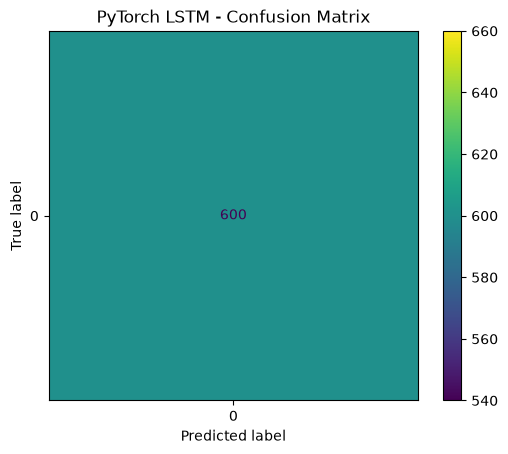

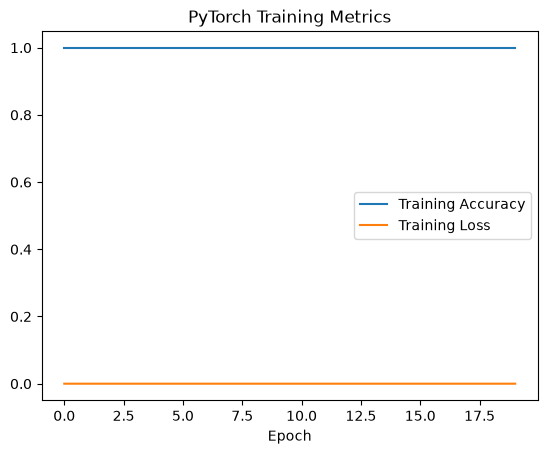


Message: Congratulations! You have won a free prize
Prediction: Ham
Spam probability: 0.0

Message: Hey, are we meeting today?
Prediction: Ham
Spam probability: 0.0


In [22]:

# 12. Evaluate on test data
model.eval()

with torch.no_grad():
    test_logits = model(X_test_t.to(device))
    test_prob = torch.sigmoid(test_logits).cpu().numpy().ravel()

y_pred = (test_prob >= 0.5).astype(int)

print("\nTest accuracy:", accuracy_score(y_test_np, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test_np,
    y_pred,
))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_np, y_pred)
).plot()

plt.title("PyTorch LSTM - Confusion Matrix")
plt.show()

# 13. Plot training metrics
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(train_losses, label="Training Loss")

plt.title("PyTorch Training Metrics")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# 14. Test a new SMS
def predict_sms(message):
    sequence = encode_text(message)
    tensor = torch.tensor(
        [sequence],
        dtype=torch.long
    ).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(tensor)
        probability = torch.sigmoid(logits).item()

    print("\nMessage:", message)
    print("Prediction:", "Spam" if probability >= 0.5 else "Ham")
    print("Spam probability:", round(probability, 4))


predict_sms("Congratulations! You have won a free prize")
predict_sms("Hey, are we meeting today?")